In [69]:
import yaml
import pandas as pd
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

In [36]:
with open("../src/config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

df = pd.read_csv(config["paths"]["raw_data"])

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


In [37]:
print(df.columns.tolist())

['country', 'iso', 'sex', 'year_of_birth', 'mean_height_(cm)', 'mean_height_lower_95%_uncertainty_interval_(cm)', 'mean_height_upper_95%_uncertainty_interval_(cm)']


In [58]:
print("Linhas antes dos filtros:", len(df))

Linhas antes dos filtros: 40400


Filtrar pelo sexo feminino

In [40]:
df_sex = df[df["sex"] == config["filters"]["sex"]]
print("Linhas após filtro de sexo:", len(df_sex))

Linhas após filtro de sexo: 20200


Usar o maior ano disponivel

In [41]:
df_maior_ano = df_sex[df_sex["year_of_birth"] == df_sex["year_of_birth"].max()]
print("Linhas após filtro do ano mais recente:", len(df_maior_ano))

Linhas após filtro do ano mais recente: 200


Media Global

In [42]:
media_global = df_maior_ano["mean_height_(cm)"].mean()
print(f"Altura média global: {media_global:.2f} cm")

Altura média global: 159.49 cm


In [61]:
df_maior_ano[df_maior_ano["iso"] == "RUS"]

,country,iso,sex,year_of_birth,mean_height_(cm),mean_height_lower_95%_uncertainty_interval_(cm),mean_height_upper_95%_uncertainty_interval_(cm)
35147,Russian Federation,RUS,Women,1996,165.270495,163.972692,166.628603


Altura das mulheres na Russia

In [60]:
altura_m_russia = (
    df_maior_ano
    .loc[df_maior_ano["country"] == "Russian Federation"]["mean_height_(cm)"]
    .iloc[0]
)
print(f"Altura média na Rússia: {altura_m_russia:.2f} cm")

Altura média na Rússia: 165.27 cm


Probabilidade de uma mulher russa ter 159

In [67]:
desvio_padrao_estimado = 0
for desvio_padrao_estimado in [5, 6, 7]:
    probabilidade = norm.cdf(
        media_global,
        loc=altura_m_russia,
        scale=desvio_padrao_estimado)
    print(f"Probabilidade com desvio padrão {desvio_padrao_estimado}: {probabilidade:.4f}")

Probabilidade com desvio padrão 5: 0.1239
Probabilidade com desvio padrão 6: 0.1677
Probabilidade com desvio padrão 7: 0.2045


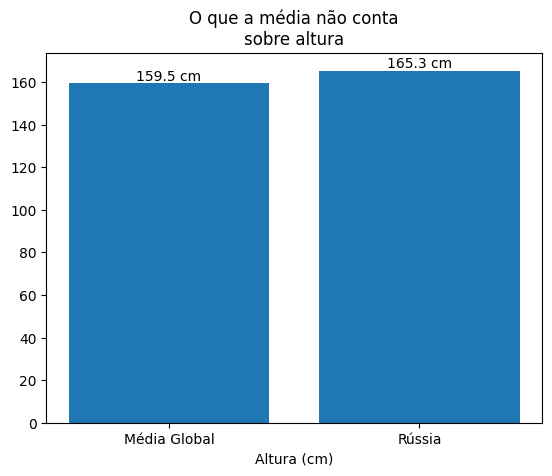

In [73]:
labels = ["Média Global", "Rússia"]
valores = [media_global, altura_m_russia]

# criar gráfico
plt.figure()
barras = plt.bar(labels,valores)

plt.xlabel("Altura (cm)")
plt.title("O que a média não conta\nsobre altura")

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2,
    altura,
    f"{altura:.1f} cm",
    ha="center",
    va="bottom")

plt.show()